<a href="https://colab.research.google.com/github/Bienbaz/Feature-Engineering-NBA-Player-Longevity-Prediction/blob/main/nba_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering: NBA Player Longevity Prediction

This notebook addresses data exploration, feature extraction, multicollinearity reduction, feature scaling, and provides stakeholder insights based on the `nba-players.csv` dataset.

### Step 0: Upload the Required Dataset
**CRITICAL INSTRUCTION:** Before running the code below, upload the `nba-players.csv` file to your Google Colab environment.
1. Click the Folder icon on the left sidebar.
2. Click the 'Upload to session storage' icon.
3. Select `nba-players.csv` from your computer.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

print('Libraries successfully imported.')

Libraries successfully imported.


### Step 1: Load Data & Data Exploration (Class Balance)
We will load the dataset and explicitly check the distribution of our target variable `target_5yrs` to ensure there isn't a severe class imbalance.

,Unnamed: 0,name,gp,min,pts,fgm,fga,fg,3p_made,3pa,...,fta,ft,oreb,dreb,reb,ast,stl,blk,tov,target_5yrs
0,0,Brandon Ingram,36,27.4,7.4,2.6,7.6,34.7,0.5,2.1,...,2.3,69.9,0.7,3.4,4.1,1.9,0.4,0.4,1.3,0
1,1,Andrew Harrison,35,26.9,7.2,2.0,6.7,29.6,0.7,2.8,...,3.4,76.5,0.5,2.0,2.4,3.7,1.1,0.5,1.6,0
2,2,JaKarr Sampson,74,15.3,5.2,2.0,4.7,42.2,0.4,1.7,...,1.3,67.0,0.5,1.7,2.2,1.0,0.5,0.3,1.0,0
3,3,Malik Sealy,58,11.6,5.7,2.3,5.5,42.6,0.1,0.5,...,1.3,68.9,1.0,0.9,1.9,0.8,0.6,0.1,1.0,1
4,4,Matt Geiger,48,11.5,4.5,1.6,3.0,52.4,0.0,0.1,...,1.9,67.4,1.0,1.5,2.5,0.3,0.3,0.4,0.8,1



--- Target Variable Distribution (target_5yrs) ---
target_5yrs
1    62.014925
0    37.985075
Name: proportion, dtype: float64


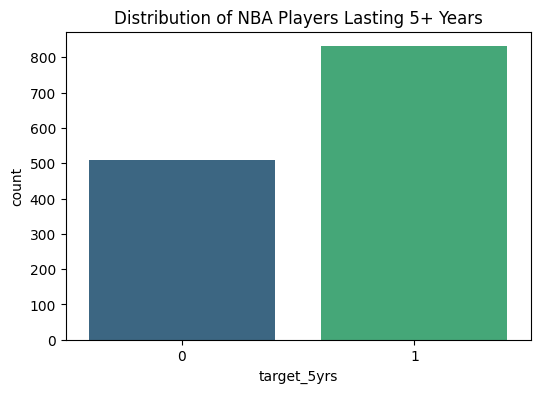

In [2]:
try:
    df = pd.read_csv('nba-players.csv')
    display(df.head())

    print('\n--- Target Variable Distribution (target_5yrs) ---')
    print(df['target_5yrs'].value_counts(normalize=True) * 100)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x='target_5yrs', palette='viridis')
    plt.title('Distribution of NBA Players Lasting 5+ Years')
    plt.show()
except FileNotFoundError:
    print('ERROR: nba-players.csv not found. Please upload it first.')

### Step 2: Noise Reduction & Feature Transformation (Handling Missing Values)
Non-predictive features like player names cause data leakage and add noise. Furthermore, missing values (like a missing 3-point percentage when 3-point attempts are 0) must be handled for ML algorithms to function.

In [3]:
# Drop non-predictive columns (Noise Reduction)
if 'name' in df.columns:
    df = df.drop(columns=['name'])
    print('Dropped non-predictive column: name')

# Handle missing values by imputing 0.0 (Feature Transformation)
print('\nMissing values before imputation:', df.isnull().sum().sum())
df = df.fillna(0.0)
print('Missing values after imputation:', df.isnull().sum().sum())

Dropped non-predictive column: name

Missing values before imputation: 0
Missing values after imputation: 0


### Step 3: Multicollinearity & Correlation Analysis
Highly correlated features (e.g., Field Goals Made and Total Points) provide redundant information to an ML model. We will map correlations and drop redundant sub-metrics.

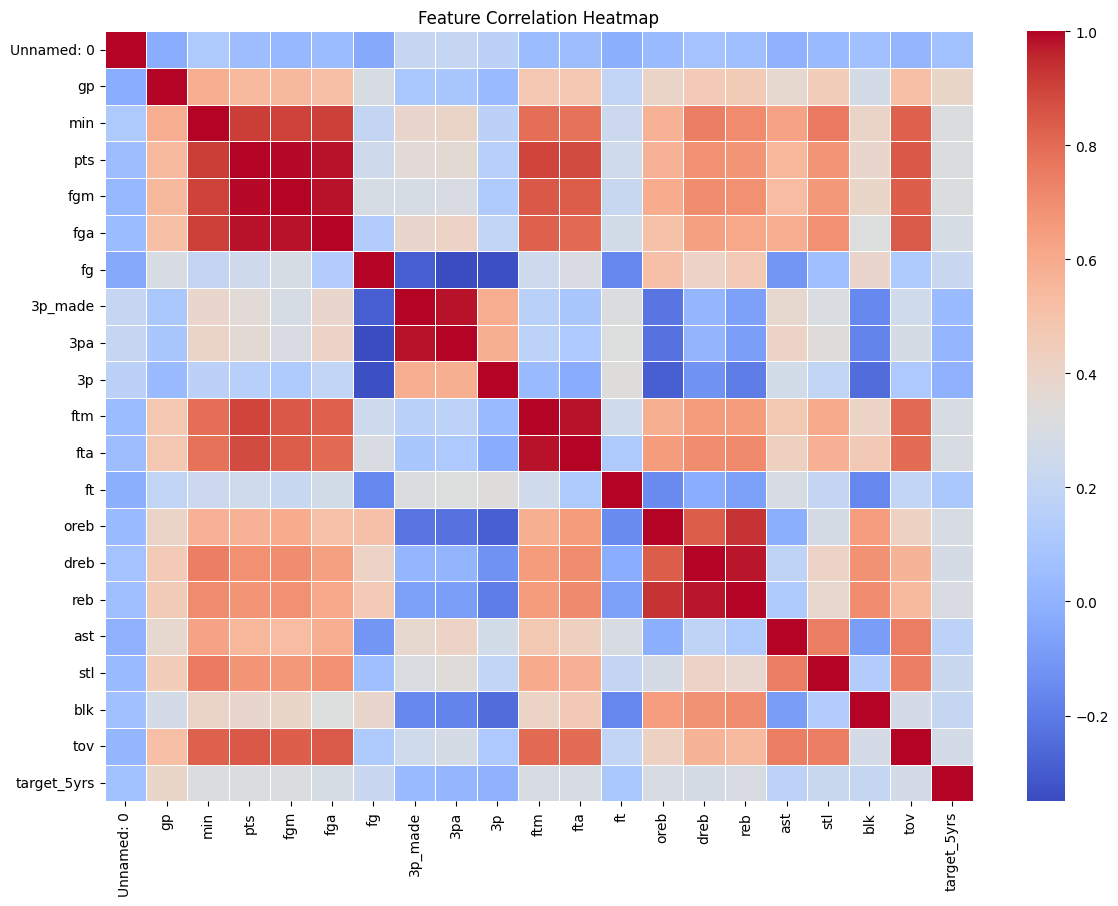


Dropped redundant columns: ['fgm', 'fga', '3pm', '3pa', 'ftm', 'fta']


In [4]:
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

# Drop redundant metrics to reduce multicollinearity
redundant_cols = ['fgm', 'fga', '3pm', '3pa', 'ftm', 'fta']
df_reduced = df.drop(columns=[col for col in redundant_cols if col in df.columns])
print('\nDropped redundant columns:', redundant_cols)

### Step 4: Feature Extraction (Engineering a Composite Metric)
We will create `Efficiency_Per_Min` to measure a player's impact independent of their court time.

In [5]:
# Formula: (Points + Rebounds + Assists) / Minutes Played
df_reduced['Efficiency_Per_Min'] = (df_reduced['pts'] + df_reduced['reb'] + df_reduced['ast']) / (df_reduced['min'] + 0.1)

display(df_reduced[['min', 'pts', 'reb', 'ast', 'Efficiency_Per_Min']].head())

,min,pts,reb,ast,Efficiency_Per_Min
0,27.4,7.4,4.1,1.9,0.487273
1,26.9,7.2,2.4,3.7,0.492593
2,15.3,5.2,2.2,1.0,0.545455
3,11.6,5.7,1.9,0.8,0.717949
4,11.5,4.5,2.5,0.3,0.629310


### Step 5: Feature Scaling
Machine learning models (like SVM or KNN) evaluate distance. If 'minutes' is in the thousands and 'steals' is in the single digits, the model will be biased. We will apply `StandardScaler` to normalize the ranges.

In [6]:
scaler = StandardScaler()

# Separate target
X = df_reduced.drop(columns=['target_5yrs'])
y = df_reduced['target_5yrs']

# Fit and transform features
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Feature Scaling complete. First 5 rows of scaled data:')
display(X_scaled.head())

Feature Scaling complete. First 5 rows of scaled data:


,Unnamed: 0,gp,min,pts,fg,3p_made,3p,ft,oreb,dreb,reb,ast,stl,blk,tov,Efficiency_Per_Min
0,-1.730759,-1.400901,1.177066,0.137401,-1.543407,0.658041,0.364603,-0.037855,-0.398290,1.010852,0.517997,0.237640,-0.533458,0.073254,0.147338,-1.203343
1,-1.728174,-1.458281,1.116860,0.091486,-2.374651,1.179494,0.271121,0.586286,-0.655746,-0.018938,-0.308447,1.461613,1.175502,0.306415,0.562695,-1.155901
2,-1.725588,0.779563,-0.279912,-0.367659,-0.320991,0.397315,0.327210,-0.312099,-0.655746,-0.239607,-0.405676,-0.374347,-0.289321,-0.159906,-0.268019,-0.684484
3,-1.723003,-0.138527,-0.725434,-0.252873,-0.255795,-0.384863,0.215032,-0.132422,-0.012104,-0.828059,-0.551519,-0.510344,-0.045184,-0.626228,-0.268019,0.853798
4,-1.720418,-0.712333,-0.737475,-0.528360,1.341496,-0.645589,-1.193430,-0.274272,-0.012104,-0.386720,-0.259833,-0.850337,-0.777595,0.073254,-0.544923,0.063332


### Step 6: Insights & Stakeholder Summary
Based on our correlation matrix, the strongest predictors of a player lasting 5+ years in the NBA are **Games Played (gp)**, **Minutes Played (min)**, and **Points (pts)**. By stripping away the highly correlated underlying attempts (`fga`, `fta`) and standardizing the scale of all remaining statistics, we have created a robust, mathematically sound dataset. The engineered `Efficiency_Per_Min` feature will further allow downstream models to identify high-impact players who may not have received extensive rookie court time.